In [1]:
import os
import re

import json
import pandas as pd
import matplotlib.pyplot as plt


In [2]:

path_foulder = "C:/Users/es25591/Workspace/CacheVideoPredict360/Results/" + "2026-03-06_13-01/"
# path_foulder = "/home/eduardo/Workspace/CacheVideoPredict360/Results/" + "2026-03-06_08-17/"

pattern = re.compile(r"^debug_ep(\d+)\.json$")
records = []

for file_name in os.listdir(path_foulder):
    match = pattern.match(file_name)
    if not match:
        continue

    episode_index = int(match.group(1))
    file_path = os.path.join(path_foulder, file_name)

    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if isinstance(data, dict):
        records.append({"episode_index": episode_index, **data})
    else:
        records.append({"episode_index": episode_index, "data": data})

records.sort(key=lambda x: x["episode_index"])
df = pd.DataFrame(records)


In [3]:
# Explore available columns and data types
print("Available columns in records:")
print(records[0].keys())
print("\nDataFrame columns:")
print(df.columns.tolist())
print("\nDataFrame dtypes:")
print(df.dtypes)

Available columns in records:
dict_keys(['episode_index', 'reward', 'psnr', 'cache_hits', 'cache_misses', 'backhaul_usage', 'base_layer_miss', 'enh_0_action', 'enh_1_action', 'enh_2_action', 'enh_3_action', 'enh_layer_missing_1', 'enh_layer_missing_2', 'enh_layer_missing_3', 'enh_layer_missing_4', 'tile_viewport', 'base_action', 'train_loss_combined', 'train_loss_base', 'train_loss_enh', 'epsilon_combined', 'lr', 'epsilon'])

DataFrame columns:
['episode_index', 'reward', 'psnr', 'cache_hits', 'cache_misses', 'backhaul_usage', 'base_layer_miss', 'enh_0_action', 'enh_1_action', 'enh_2_action', 'enh_3_action', 'enh_layer_missing_1', 'enh_layer_missing_2', 'enh_layer_missing_3', 'enh_layer_missing_4', 'tile_viewport', 'base_action', 'train_loss_combined', 'train_loss_base', 'train_loss_enh', 'epsilon_combined', 'lr', 'epsilon']

DataFrame dtypes:
episode_index           int64
reward                 object
psnr                   object
cache_hits             object
cache_misses           o

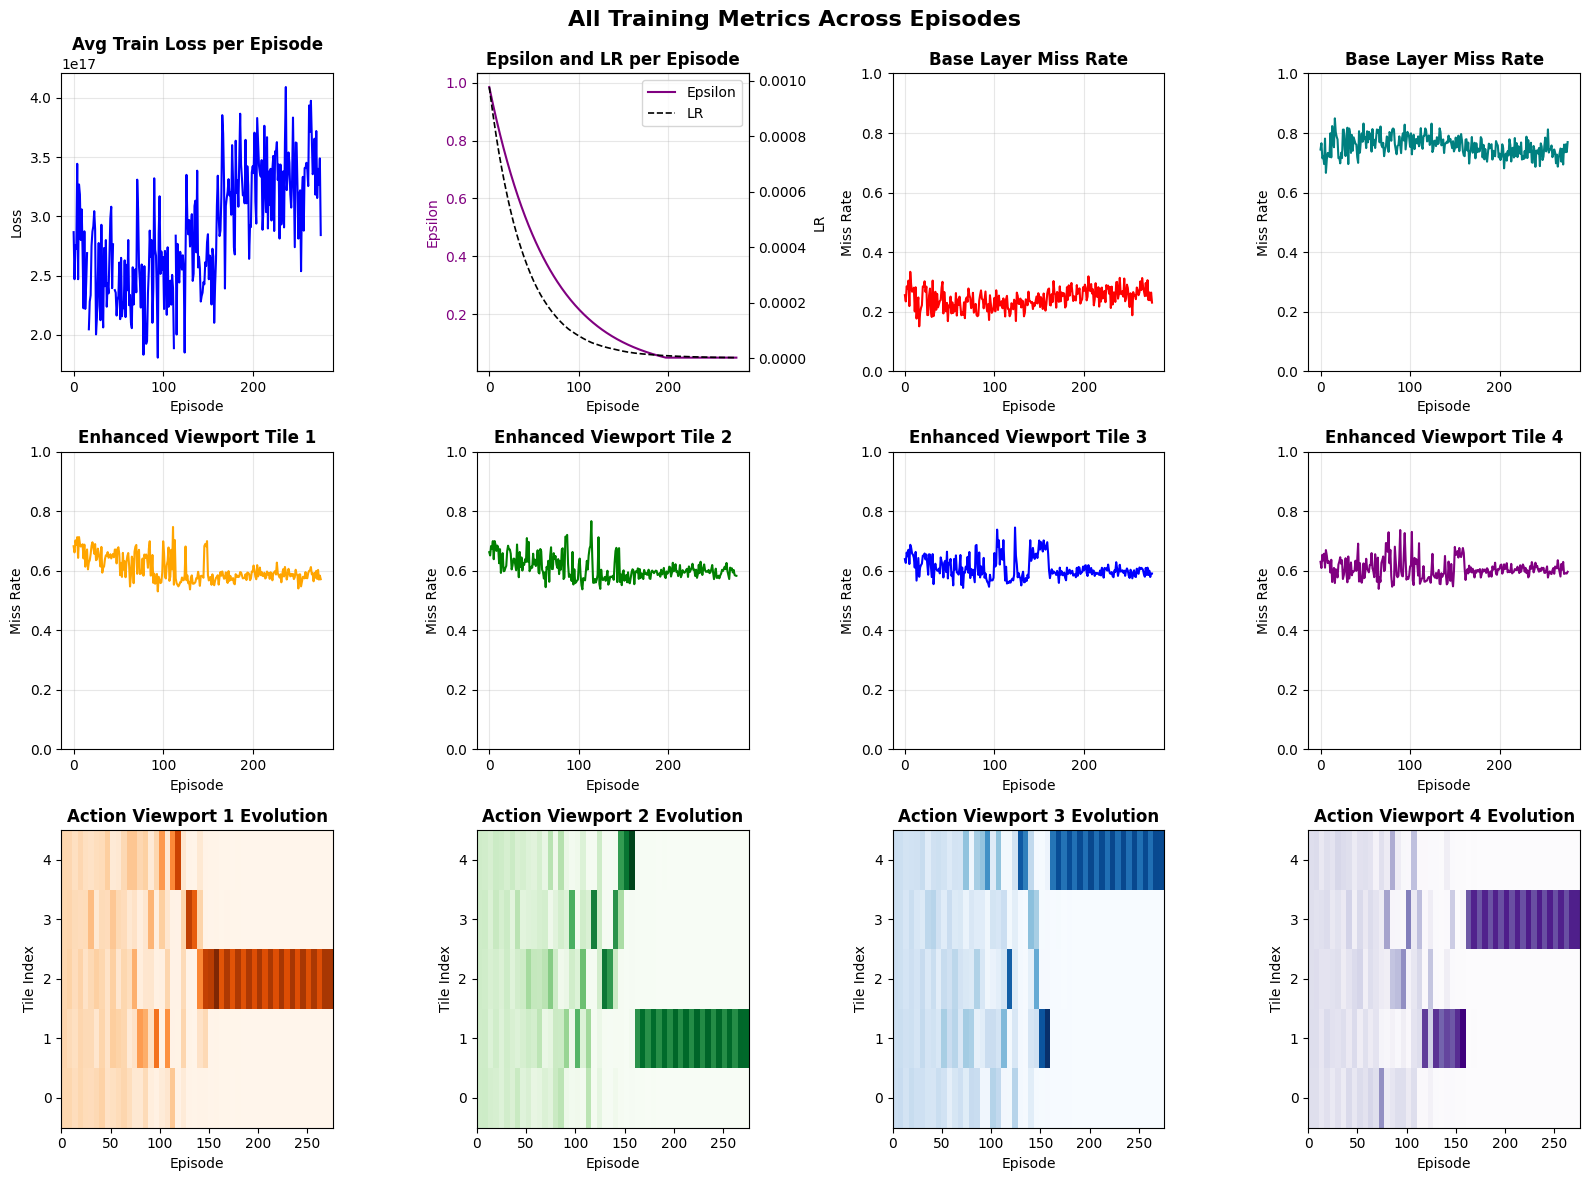

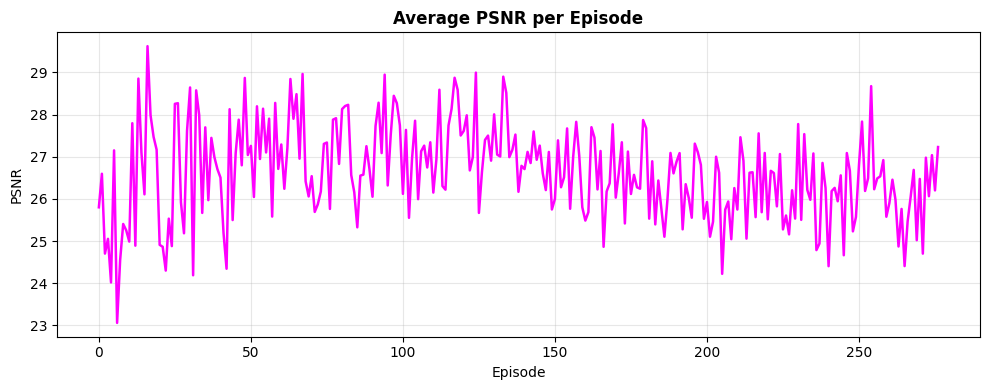

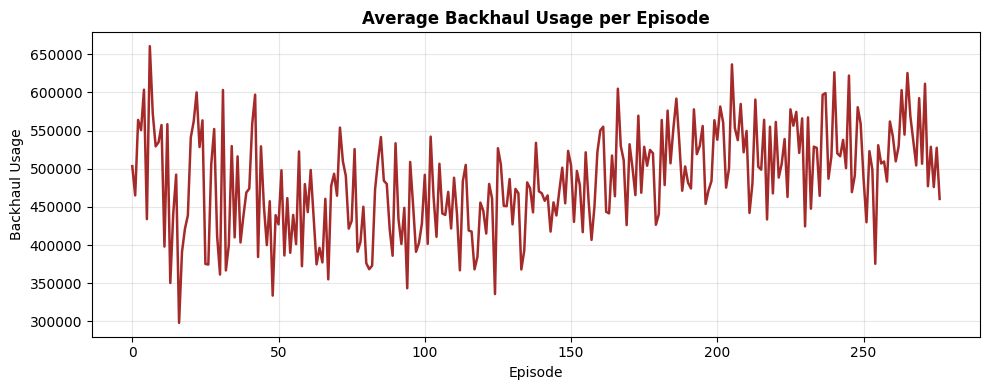

Total episodes: 277
Data contains metrics for: base layer + 4 enhancement layers


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create comprehensive charts for all metrics
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('All Training Metrics Across Episodes', fontsize=16, fontweight='bold')

# Helper function to compute average from list columns
def get_avg_per_episode(col_name):
    return [sum(val)/len(val) if isinstance(val, list) else val 
            for val in df[col_name]]

# NEW Helper: Gets (episode, action) pairs to track evolution over time
def get_episode_action_pairs(col_name):
    episodes_list = []
    actions_list = []
    for ep, val in zip(df['episode_index'], df[col_name]):
        if isinstance(val, list):
            actions_list.extend(val)
            episodes_list.extend([ep] * len(val))
        elif pd.notna(val):
            actions_list.append(val)
            episodes_list.append(ep)
    return episodes_list, actions_list

# NEW Plotter: 2D Histogram (Heatmap) for evolution
def plot_action_evolution(ax, col_name, title, cmap):
    eps, acts = get_episode_action_pairs(col_name)
    
    if len(acts) == 0:
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Cache Index')
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.grid(True, alpha=0.3)
        return

    vmin = int(min(acts))
    vmax = int(max(acts))
    
    # Bins: Y-axis (tiles) gets exactly 1 bin per tile index. 
    # X-axis (episodes) is binned dynamically to avoid overcrowding if you have thousands of episodes.
    y_bins = np.arange(vmin, vmax + 2) - 0.5 # -0.5 centers the bins on the integer ticks
    num_unique_eps = len(set(eps))
    x_bins = min(num_unique_eps, 50) # Caps episode bins at 50 for visual clarity
    
    # Plot the 2D Histogram
    h = ax.hist2d(eps, acts, bins=[x_bins, y_bins], cmap=cmap, cmin=1)
    
    # Formatting
    ax.set_yticks(range(vmin, vmax + 1))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Tile Index')
    
    # Optional: Fill background with a very light gray so zero-frequency areas stand out from the colormap
    ax.set_facecolor('#f0f0f0')

episodes = df['episode_index'].values

# 1. Train Loss Average
ax = axes[0, 0]
avg_train_loss = get_avg_per_episode('train_loss_combined')
ax.plot(episodes, avg_train_loss, color='blue', linewidth=1.5)
ax.set_title('Avg Train Loss per Episode', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.grid(True, alpha=0.3)

# 2. Epsilon and LR (exploration + learning rate)
ax = axes[0, 1]
avg_epsilon = get_avg_per_episode('epsilon')
avg_lr = get_avg_per_episode('lr')
line_eps, = ax.plot(episodes, avg_epsilon, color='purple', linewidth=1.5, label='Epsilon')
ax.set_title('Epsilon and LR per Episode', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Epsilon', color='purple')
ax.tick_params(axis='y', labelcolor='purple')
ax.grid(True, alpha=0.3)

ax_lr = ax.twinx()
line_lr, = ax_lr.plot(episodes, avg_lr, color='black', linestyle='--', linewidth=1.2, label='LR')
ax_lr.set_ylabel('LR', color='black')
ax_lr.tick_params(axis='y', labelcolor='black')
ax.legend([line_eps, line_lr], ['Epsilon', 'LR'], loc='best')

# 3. Base Layer Miss
ax = axes[0, 2]
avg_base_miss = get_avg_per_episode('base_layer_miss')
ax.plot(episodes, avg_base_miss, color='red', linewidth=1.5)
ax.set_title('Base Layer Miss Rate', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Miss Rate')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# 4. Base Layer Hits
ax = axes[0, 3]
avg_base_hits = [1 - miss for miss in avg_base_miss]
ax.plot(episodes, avg_base_hits, color='teal', linewidth=1.5)
ax.set_title('Base Layer Miss Rate', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Miss Rate')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

#### 4. Base Layer Action Evolution #######
# ax = axes[0, 3]
# plot_action_evolution(ax, 'base_action', 'Base Layer Action Evolution', 'Reds')
############

# Enhancement Layer 1
ax = axes[1, 0]
avg_enh1_miss = get_avg_per_episode('enh_layer_missing_1')
ax.plot(episodes, avg_enh1_miss, color='orange', linewidth=1.5)
ax.set_title('Enhanced Viewport Tile 1', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Miss Rate')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# Enhancement Layer 2
ax = axes[1, 1]
avg_enh2_miss = get_avg_per_episode('enh_layer_missing_2')
ax.plot(episodes, avg_enh2_miss, color='green', linewidth=1.5)
ax.set_title('Enhanced Viewport Tile 2', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Miss Rate')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# Enhancement Layer 3
ax = axes[1, 2]
avg_enh3_miss = get_avg_per_episode('enh_layer_missing_3')
ax.plot(episodes, avg_enh3_miss, color='blue', linewidth=1.5)
ax.set_title('Enhanced Viewport Tile 3', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Miss Rate')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

# Enhancement Layer 4
ax = axes[1, 3]
avg_enh4_miss = get_avg_per_episode('enh_layer_missing_4')
ax.plot(episodes, avg_enh4_miss, color='purple', linewidth=1.5)
ax.set_title('Enhanced Viewport Tile 4', fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Miss Rate')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

ax = axes[2, 0]
plot_action_evolution(ax, 'enh_0_action', 'Action Viewport 1 Evolution', 'Oranges')

ax = axes[2, 1]
plot_action_evolution(ax, 'enh_1_action', 'Action Viewport 2 Evolution', 'Greens')

ax = axes[2, 2]
plot_action_evolution(ax, 'enh_2_action', 'Action Viewport 3 Evolution', 'Blues')

ax = axes[2, 3]
plot_action_evolution(ax, 'enh_3_action', 'Action Viewport 4 Evolution', 'Purples')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Extra chart: Average PSNR per episode
# ----------------------------------------------------------------
def get_psnr_avg_per_episode():
    if 'psnr' in df.columns:
        return get_avg_per_episode('psnr')
    if 'psnr_avg' in df.columns:
        return get_avg_per_episode('psnr_avg')
    if 'reward_layer_0' in df.columns and 'reward_layer_1' in df.columns:
        r0 = get_avg_per_episode('reward_layer_0')
        r1 = get_avg_per_episode('reward_layer_1')
        return [a + b for a, b in zip(r0, r1)]
    return None

psnr_avg = get_psnr_avg_per_episode()

fig_psnr, ax_psnr = plt.subplots(figsize=(10, 4))
if psnr_avg is None:
    ax_psnr.text(0.5, 0.5, 'No PSNR-related columns found in DataFrame', ha='center', va='center', transform=ax_psnr.transAxes)
    ax_psnr.set_title('Average PSNR per Episode', fontweight='bold')
    ax_psnr.set_xlabel('Episode')
    ax_psnr.set_ylabel('PSNR')
    ax_psnr.grid(True, alpha=0.3)
else:
    ax_psnr.plot(episodes, psnr_avg, color='magenta', linewidth=1.8)
    ax_psnr.set_title('Average PSNR per Episode', fontweight='bold')
    ax_psnr.set_xlabel('Episode')
    ax_psnr.set_ylabel('PSNR')
    ax_psnr.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Extra chart: Average backhaul usage per episode
# ----------------------------------------------------------------
def get_backhaul_avg_per_episode():
    if 'backhaul_usage' in df.columns:
        return get_avg_per_episode('backhaul_usage')
    if 'backhaul' in df.columns:
        return get_avg_per_episode('backhaul')
    return None

backhaul_avg = get_backhaul_avg_per_episode()

fig_bh, ax_bh = plt.subplots(figsize=(10, 4))
if backhaul_avg is None:
    ax_bh.text(0.5, 0.5, 'No backhaul_usage/backhaul column found in DataFrame', ha='center', va='center', transform=ax_bh.transAxes)
    ax_bh.set_title('Average Backhaul Usage per Episode', fontweight='bold')
    ax_bh.set_xlabel('Episode')
    ax_bh.set_ylabel('Backhaul Usage')
    ax_bh.grid(True, alpha=0.3)
else:
    ax_bh.plot(episodes, backhaul_avg, color='brown', linewidth=1.8)
    ax_bh.set_title('Average Backhaul Usage per Episode', fontweight='bold')
    ax_bh.set_xlabel('Episode')
    ax_bh.set_ylabel('Backhaul Usage')
    ax_bh.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total episodes: {len(episodes)}")
print(f"Data contains metrics for: base layer + 4 enhancement layers")

KeyError: 'train_loss'

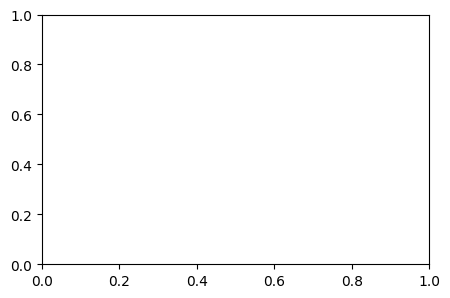

In [5]:
# Group related metrics for focused analysis
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Training Convergence (Top-left)
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(episodes, get_avg_per_episode('train_loss'), label='Meta Loss', color='#1f77b4', linewidth=2)
ax1.plot(episodes, get_avg_per_episode('train_loss_ctrl'), label='Ctrl Loss', color='#ff7f0e', linewidth=2)
ax1.set_title('Training Loss Convergence', fontweight='bold', fontsize=12)
ax1.set_xlabel('Episode')
ax1.set_ylabel('Loss')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 3. Cache Performance (Top-right)
ax2 = fig.add_subplot(gs[0, 1])
hits = get_avg_per_episode('cache_hits')
misses = get_avg_per_episode('cache_misses')
hit_rate = [h / (h + m + 1e-9) * 100 for h, m in zip(hits, misses)]
ax2.plot(episodes, hit_rate, color='#9467bd', linewidth=2, marker='o', markersize=3)
ax2.set_title('Cache Hit Rate', fontweight='bold', fontsize=12)
ax2.set_xlabel('Episode')
ax2.set_ylabel('Hit Rate (%)')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 100])

# 6. Enhancement Layer Miss Rates (Middle-right)
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(episodes, get_avg_per_episode('enh_layer_missing_0'), label='Enh 0', linewidth=2)
ax3.plot(episodes, get_avg_per_episode('enh_layer_missing_1'), label='Enh 1', linewidth=2)
ax3.plot(episodes, get_avg_per_episode('enh_layer_missing_2'), label='Enh 2', linewidth=2)
ax3.plot(episodes, get_avg_per_episode('enh_layer_missing_3'), label='Enh 3', linewidth=2)
ax3.set_title('Enhancement Layer Miss Rates', fontweight='bold', fontsize=12)
ax3.set_xlabel('Episode')
ax3.set_ylabel('Miss Rate')
ax3.legend(loc='best', fontsize=8)
ax3.grid(True, alpha=0.3)

# 7. Reward Metrics (Bottom-left)
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(episodes, get_avg_per_episode('reward'), label='Step Reward', color='#bcbd22', linewidth=2, alpha=0.8)
ax4.set_title('Reward Metrics', fontweight='bold', fontsize=12)
ax4.set_xlabel('Episode')
ax4.set_ylabel('Reward')
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3)

# 8. Cache Hits vs Misses (Bottom-middle)
ax5 = fig.add_subplot(gs[1, 1])
ax5_twin = ax5.twinx()
line1 = ax5.plot(episodes, hits, label='Hits', color='#1f77b4', linewidth=2)
line2 = ax5_twin.plot(episodes, misses, label='Misses', color='#d62728', linewidth=2)
ax5.set_title('Cache Hits vs Misses', fontweight='bold', fontsize=12)
ax5.set_xlabel('Episode')
ax5.set_ylabel('Cache Hits', color='#1f77b4')
ax5_twin.set_ylabel('Cache Misses', color='#d62728')
ax5.tick_params(axis='y', labelcolor='#1f77b4')
ax5_twin.tick_params(axis='y', labelcolor='#d62728')
ax5.grid(True, alpha=0.3)
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax5.legend(lines, labels, loc='upper right', fontsize=8)

# Tile request distribution across all episodes (tile IDs 0-11)
ax6 = fig.add_subplot(gs[1, 2])
tile_requests = []
for v in df['tile_viewport']:
    if isinstance(v, (list, tuple, np.ndarray)):
        tile_requests.extend([int(t) for t in v if pd.notna(t)])
    elif pd.notna(v):
        tile_requests.append(int(v))

ax6.hist(
    tile_requests,
    bins=np.arange(-0.5, 12.5, 1),
    color='#8c564b',
    edgecolor='black',
    alpha=0.8
)
ax6.set_title('Tile Request Histogram (All Episodes)', fontweight='bold', fontsize=12)
ax6.set_xlabel('Tile ID')
ax6.set_ylabel('Request Count')
ax6.set_xticks(range(12))
ax6.set_xlim(-0.5, 11.5)
ax6.grid(True, alpha=0.3, axis='y')

# 9. Episode Summary Statistics (Bottom-right)
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

# Create summary statistics text
stats_text = f"""
TRAINING SUMMARY STATISTICS

Episodes: {len(episodes)}

Train Loss:
  Min: {min(get_avg_per_episode('train_loss')):.4f}
  Max: {max(get_avg_per_episode('train_loss')):.4f}
  Final: {get_avg_per_episode('train_loss')[-1]:.4f}

Epsilon Decay:
  Initial: {get_avg_per_episode('epsilon')[0]:.4f}
  Final: {get_avg_per_episode('epsilon')[-1]:.4f}

Cache Performance:
  Avg Hit Rate: {sum(hit_rate)/len(hit_rate):.2f}%
  Avg Hits: {sum(hits)/len(hits):.2f}
  Avg Misses: {sum(misses)/len(misses):.2f}

Rewards:
  Avg Step Reward: {sum(get_avg_per_episode('reward'))/len(episodes):.2f}
"""

ax9.text(0.05, 0.95, stats_text, transform=ax9.transAxes, 
         fontsize=9, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

fig.suptitle('Grouped Training Metrics Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("✓ Generated grouped analysis visualizations")

C:\Users\es25591\AppData\Local\Temp\ipykernel_13048\1260820453.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(enh_actions, labels=['Enh 0', 'Enh 1', 'Enh 2', 'Enh 3'], patch_artist=True)
C:\Users\es25591\AppData\Local\Temp\ipykernel_13048\1260820453.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(enh_missing, labels=['Enh 0', 'Enh 1', 'Enh 2', 'Enh 3'], patch_artist=True)


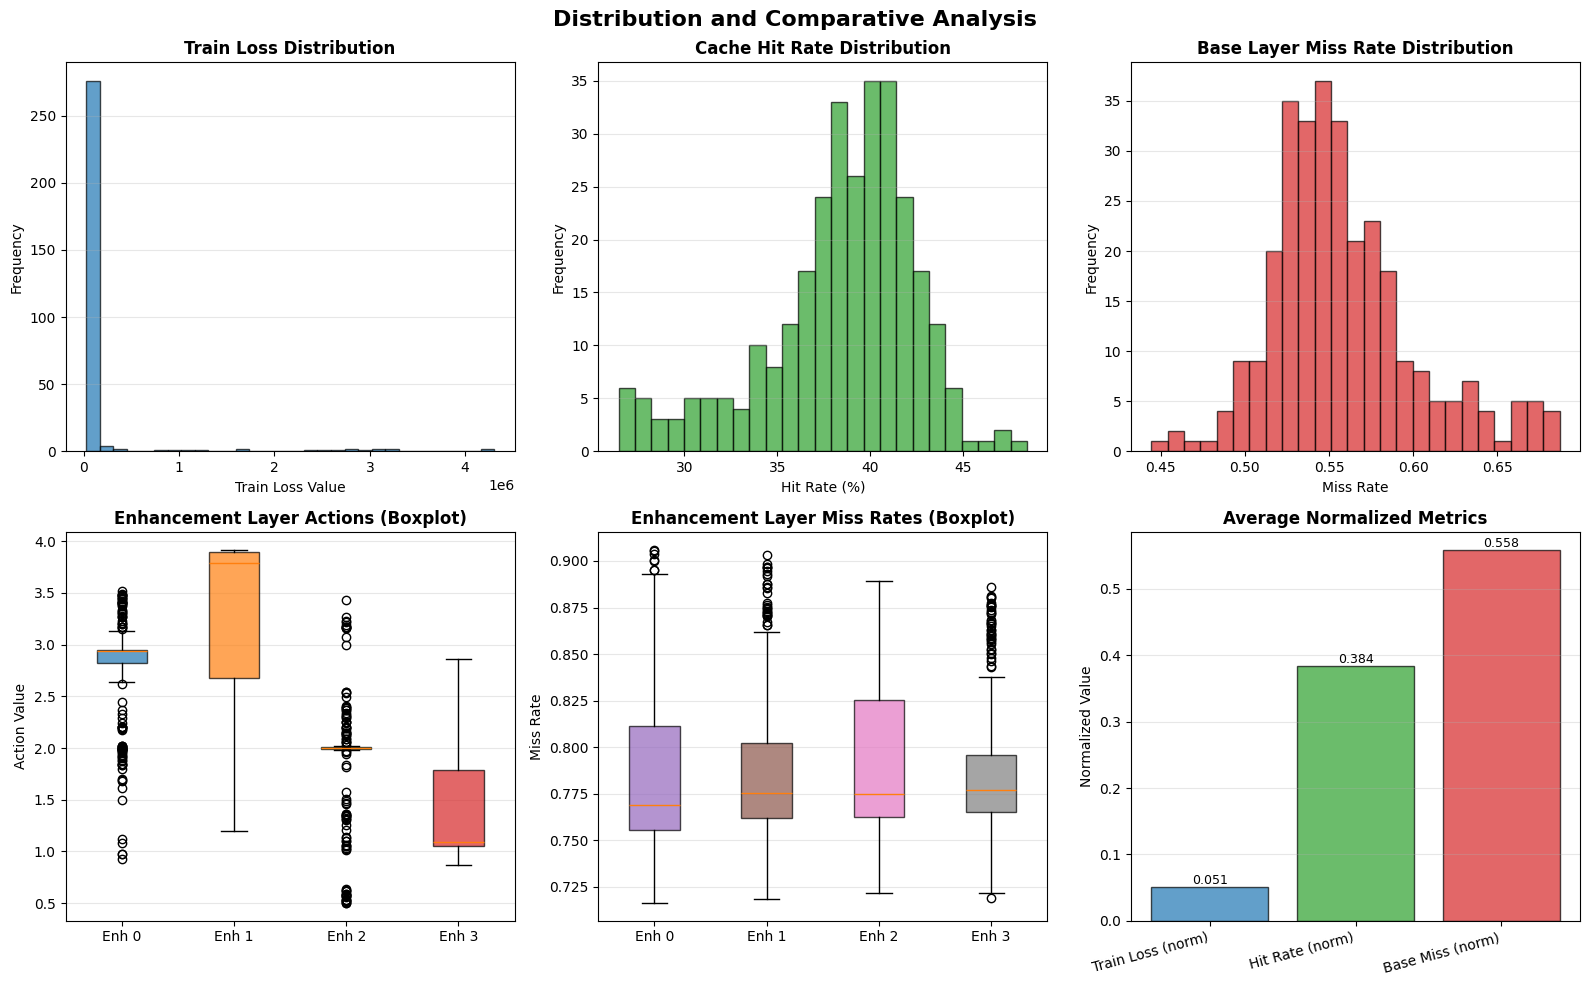


COMPARATIVE METRICS ANALYSIS

Train Loss Statistics:
  Mean: 218808.0681
  Std:  622537.3889

Cache Hit Rate Statistics:
  Mean: 38.40%
  Std:  4.10%

Base Layer Miss Rate Statistics:
  Mean: 0.5582
  Std:  0.0430

Enhancement Layer Actions Summary:
  Enh 0 - Mean: 2.7931, Range: [0.93, 3.51]
  Enh 1 - Mean: 3.2799, Range: [1.20, 3.92]
  Enh 2 - Mean: 1.9251, Range: [0.50, 3.43]
  Enh 3 - Mean: 1.3506, Range: [0.87, 2.86]

Enhancement Layer Missing Summary:
  Enh 0 - Mean: 0.7886, Range: [0.7163, 0.9061]
  Enh 1 - Mean: 0.7888, Range: [0.7184, 0.9030]
  Enh 2 - Mean: 0.7934, Range: [0.7216, 0.8893]
  Enh 3 - Mean: 0.7879, Range: [0.7189, 0.8860]



In [ ]:
# Distribution and comparative analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribution and Comparative Analysis', fontsize=16, fontweight='bold')

# 1. Train Loss Distribution (Histogram)
ax = axes[0, 0]
train_loss_data = get_avg_per_episode('train_loss')
ax.hist(train_loss_data, bins=30, color='#1f77b4', alpha=0.7, edgecolor='black')
ax.set_title('Train Loss Distribution', fontweight='bold')
ax.set_xlabel('Train Loss Value')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')

# 2. Cache Performance Distribution
ax = axes[0, 1]
hit_rate_data = [h / (h + m + 1e-9) * 100 for h, m in zip(hits, misses)]
ax.hist(hit_rate_data, bins=25, color='#2ca02c', alpha=0.7, edgecolor='black')
ax.set_title('Cache Hit Rate Distribution', fontweight='bold')
ax.set_xlabel('Hit Rate (%)')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')

# 3. Base Layer Miss Rate Distribution
ax = axes[0, 2]
base_miss_data = get_avg_per_episode('base_layer_miss')
ax.hist(base_miss_data, bins=25, color='#d62728', alpha=0.7, edgecolor='black')
ax.set_title('Base Layer Miss Rate Distribution', fontweight='bold')
ax.set_xlabel('Miss Rate')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3, axis='y')

# 4. Enhancement Layer Actions Comparison (Boxplot)
ax = axes[1, 0]
enh_actions = [
    get_avg_per_episode('enh_0_action'),
    get_avg_per_episode('enh_1_action'),
    get_avg_per_episode('enh_2_action'),
    get_avg_per_episode('enh_3_action')
]
bp = ax.boxplot(enh_actions, labels=['Enh 0', 'Enh 1', 'Enh 2', 'Enh 3'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Enhancement Layer Actions (Boxplot)', fontweight='bold')
ax.set_ylabel('Action Value')
ax.grid(True, alpha=0.3, axis='y')

# 5. Enhancement Layer Missing Comparison (Boxplot)
ax = axes[1, 1]
enh_missing = [
    get_avg_per_episode('enh_layer_missing_0'),
    get_avg_per_episode('enh_layer_missing_1'),
    get_avg_per_episode('enh_layer_missing_2'),
    get_avg_per_episode('enh_layer_missing_3')
]
bp = ax.boxplot(enh_missing, labels=['Enh 0', 'Enh 1', 'Enh 2', 'Enh 3'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#9467bd', '#8c564b', '#e377c2', '#7f7f7f']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Enhancement Layer Miss Rates (Boxplot)', fontweight='bold')
ax.set_ylabel('Miss Rate')
ax.grid(True, alpha=0.3, axis='y')

# 6. Normalized Metrics Comparison
ax = axes[1, 2]
metrics_to_compare = {
    'Train Loss (norm)': [v / (max(train_loss_data) or 1) for v in train_loss_data],
    'Hit Rate (norm)': [v / 100 for v in hit_rate_data],
    'Base Miss (norm)': [v for v in base_miss_data],
}
# Plot means as a bar chart
means = {k: sum(v) / len(v) for k, v in metrics_to_compare.items()}
colors_bar = ['#1f77b4', '#2ca02c', '#d62728']
bars = ax.bar(range(len(means)), list(means.values()), color=colors_bar, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(means)))
ax.set_xticklabels(list(means.keys()), rotation=15, ha='right')
ax.set_title('Average Normalized Metrics', fontweight='bold')
ax.set_ylabel('Normalized Value')
ax.grid(True, alpha=0.3, axis='y')

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print comparative statistics
print("\n" + "="*70)
print("COMPARATIVE METRICS ANALYSIS")
print("="*70)
print(f"\nTrain Loss Statistics:")
print(f"  Mean: {sum(train_loss_data)/len(train_loss_data):.4f}")
print(f"  Std:  {(sum((x - sum(train_loss_data)/len(train_loss_data))**2 for x in train_loss_data) / len(train_loss_data))**0.5:.4f}")

print(f"\nCache Hit Rate Statistics:")
print(f"  Mean: {sum(hit_rate_data)/len(hit_rate_data):.2f}%")
print(f"  Std:  {(sum((x - sum(hit_rate_data)/len(hit_rate_data))**2 for x in hit_rate_data) / len(hit_rate_data))**0.5:.2f}%")

print(f"\nBase Layer Miss Rate Statistics:")
print(f"  Mean: {sum(base_miss_data)/len(base_miss_data):.4f}")
print(f"  Std:  {(sum((x - sum(base_miss_data)/len(base_miss_data))**2 for x in base_miss_data) / len(base_miss_data))**0.5:.4f}")

print(f"\nEnhancement Layer Actions Summary:")
for i, enh in enumerate(enh_actions):
    mean_val = sum(enh) / len(enh)
    print(f"  Enh {i} - Mean: {mean_val:.4f}, Range: [{min(enh):.2f}, {max(enh):.2f}]")

print(f"\nEnhancement Layer Missing Summary:")
for i, enh in enumerate(enh_missing):
    mean_val = sum(enh) / len(enh)
    print(f"  Enh {i} - Mean: {mean_val:.4f}, Range: [{min(enh):.4f}, {max(enh):.4f}]")
print("="*70 + "\n")

C:\Users\es25591\AppData\Local\Temp\ipykernel_13048\265859970.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Simulation")


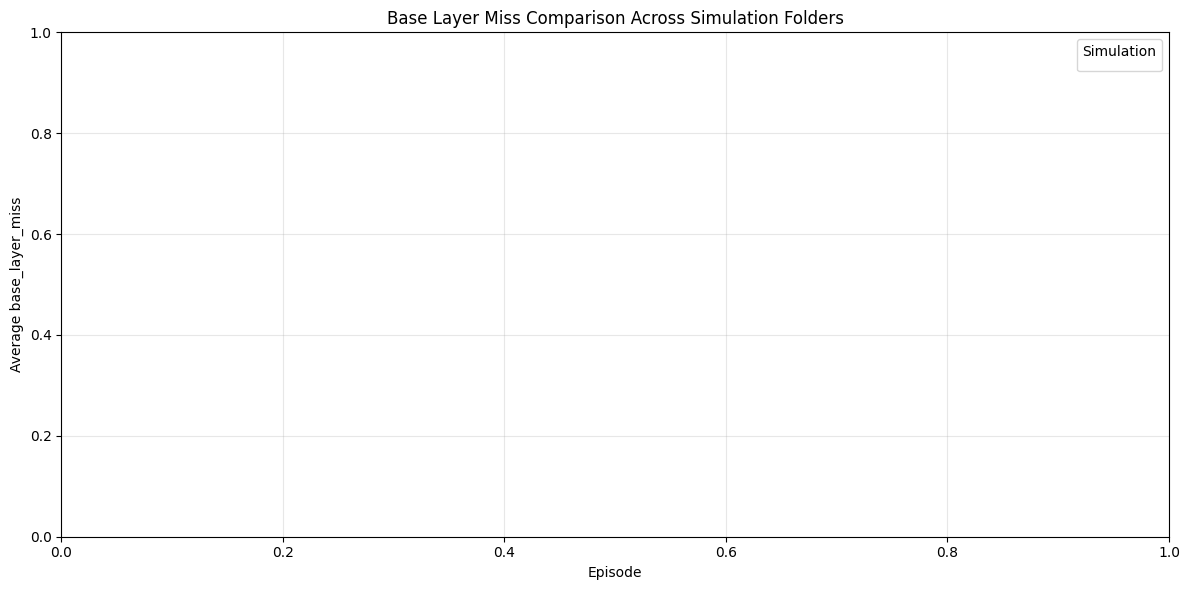

In [ ]:
# Helper function to compute average from list columns
def get_avg_per_episode(col_name, df):
    return [sum(val)/len(val) if isinstance(val, list) else val 
            for val in df[col_name]]
    
path_foulder = "/home/eduardo/Workspace/CacheVideoPredict360/Results/"
data_foulders = [
    # path_foulder + "2026-02-25_09-37/",
    # path_foulder + "2026-02-25_12-33/",
    # path_foulder + "2026-02-25_15-03/",
]

pattern = re.compile(r"^debug_ep(\d+)\.json$")

df_records = []
all_records = []
missing_folders = []

for folder in data_foulders:
    if not os.path.isdir(folder):
        missing_folders.append(folder)
        continue
    
    records = []
    for file_name in os.listdir(folder):
        match = pattern.match(file_name)
        if not match:
            continue

        episode = int(match.group(1))
        file_path = os.path.join(folder, file_name)

        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        if isinstance(data, dict):
            records.append({"episode_index": episode, **data})
        else:
            records.append({"episode_index": episode, "data": data})
        
    records.sort(key=lambda x: x["episode_index"])
    df = pd.DataFrame(records)


    avg_base_miss = get_avg_per_episode('base_layer_miss', df)
    all_records.append(avg_base_miss)
        



plt.figure(figsize=(12, 6))
for i, (folder, avg_base_miss) in enumerate(zip(data_foulders, all_records)):
    sim_name = os.path.basename(folder.rstrip('/'))
    plt.plot(
        list(range(len(avg_base_miss))),
        avg_base_miss,
        marker="o",
        markersize=3,
                linewidth=1.5,
                label=sim_name,
            )

plt.title("Base Layer Miss Comparison Across Simulation Folders")
plt.xlabel("Episode")
plt.ylabel("Average base_layer_miss")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(title="Simulation")
plt.tight_layout()
plt.show()

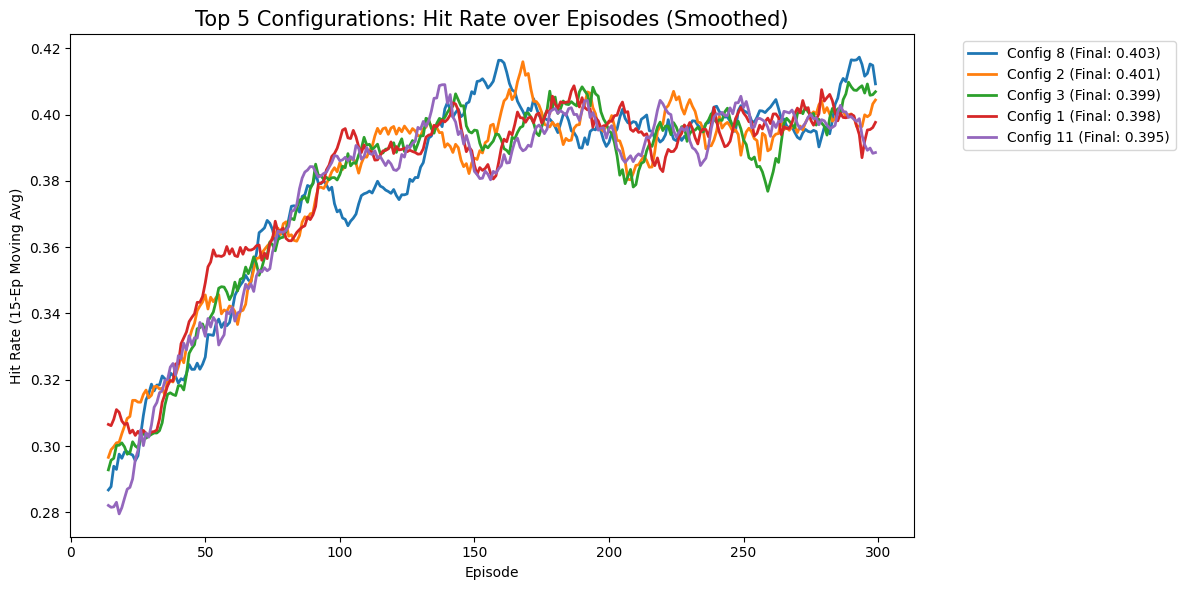

C:\Users\es25591\AppData\Local\Temp\ipykernel_13048\1191417994.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='config/optimizer', y='final_hit_rate', data=summary_df, ax=axes[0], palette='Set2')
C:\Users\es25591\AppData\Local\Temp\ipykernel_13048\1191417994.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='config/batch_size', y='final_hit_rate', data=summary_df, ax=axes[1], palette='Set3')


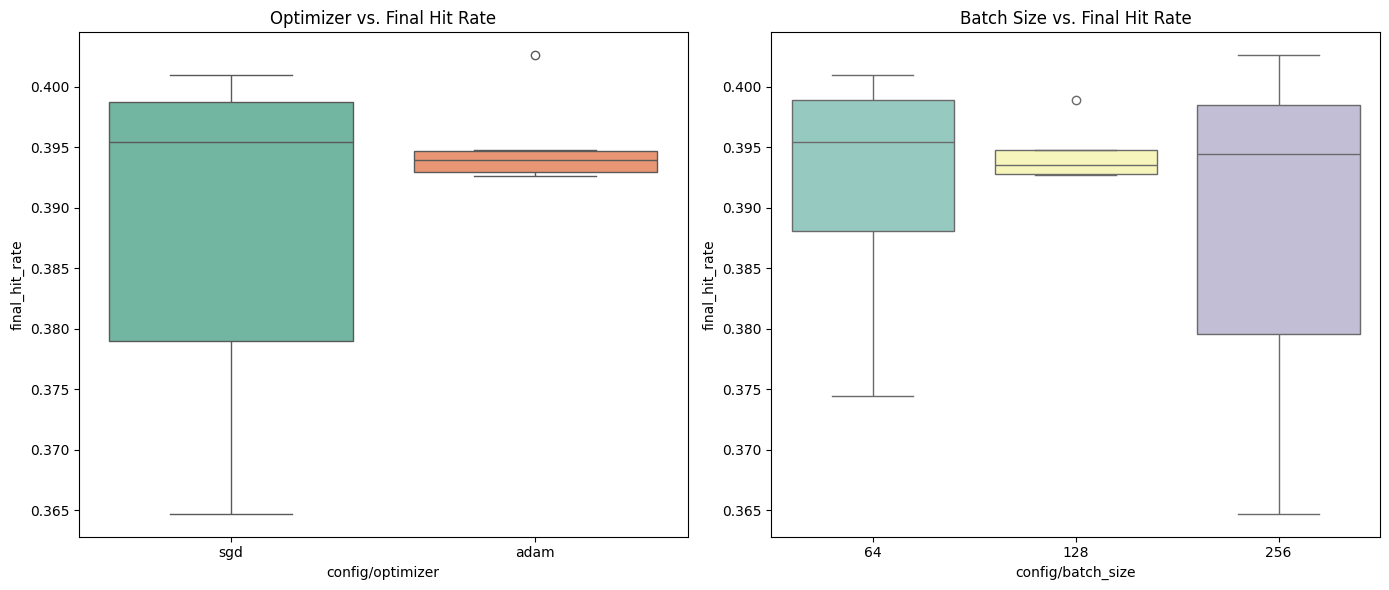

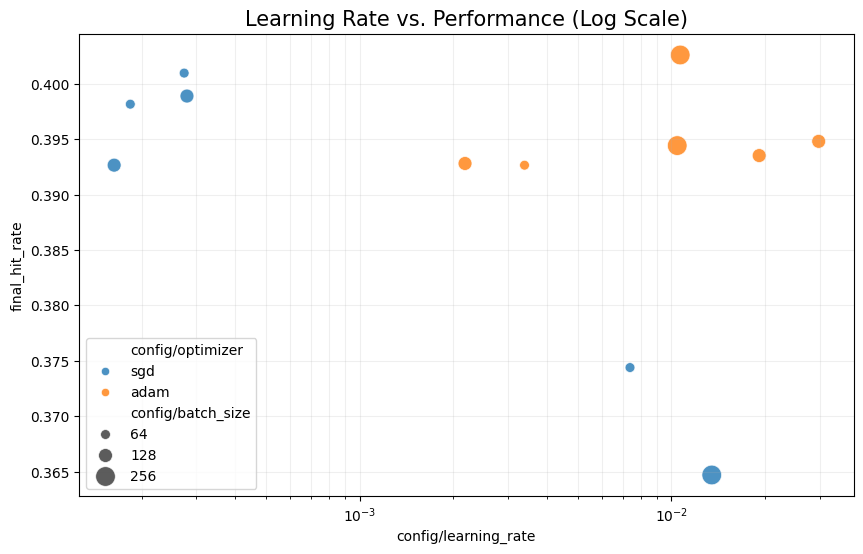

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuration & Data Loading
files = ['seed1.csv', 'seed2.csv', 'seed3.csv']
hparam_cols = ['config/learning_rate', 'config/batch_size', 'config/optimizer', 'config/hidden_dim', 'config/hidden_dims']

def generate_visualizations(file_list):

    path_foulder = "C:\\Users\\es25591\\data\\ray_tune_file_size4_method_env_default_max_160_batch\\"
    # Load and combine all seed data
    all_df = pd.concat([pd.read_csv(path_foulder + f) for f in file_list], ignore_index=True)
    
    # Create a unique ID for each specific set of hyperparameters
    all_df['config_id'] = all_df.groupby(hparam_cols).ngroup()
    
    # Aggregate data to get a single performance metric per configuration
    # We use the mean of the last 50 episodes to represent stable performance
    trial_summaries = []
    for cid, group in all_df.groupby('config_id'):
        summary = group[hparam_cols].iloc[0].to_dict()
        summary['config_id'] = cid
        summary['final_hit_rate'] = group.tail(50)['hit_rate'].mean()
        trial_summaries.append(summary)
    summary_df = pd.DataFrame(trial_summaries)

    # --- Plot 1: Top 5 Learning Curves ---
    plt.figure(figsize=(12, 6))
    top_5_ids = summary_df.sort_values('final_hit_rate', ascending=False).head(5)['config_id']
    
    for cid in top_5_ids:
        group = all_df[all_df['config_id'] == cid]
        # Smooth the curve with a rolling average for better visibility
        smoothed = group['hit_rate'].rolling(window=15).mean()
        label = f"Config {cid} (Final: {summary_df[summary_df['config_id']==cid]['final_hit_rate'].values[0]:.3f})"
        plt.plot(group['episode'], smoothed, label=label, linewidth=2)
    
    plt.title('Top 5 Configurations: Hit Rate over Episodes (Smoothed)', fontsize=15)
    plt.xlabel('Episode')
    plt.ylabel('Hit Rate (15-Ep Moving Avg)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Impact of Categorical Hyperparameters ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.boxplot(x='config/optimizer', y='final_hit_rate', data=summary_df, ax=axes[0], palette='Set2')
    axes[0].set_title('Optimizer vs. Final Hit Rate')
    
    sns.boxplot(x='config/batch_size', y='final_hit_rate', data=summary_df, ax=axes[1], palette='Set3')
    axes[1].set_title('Batch Size vs. Final Hit Rate')
    plt.tight_layout()
    plt.show()

    # --- Plot 3: Learning Rate Sensitivity ---
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='config/learning_rate', y='final_hit_rate', hue='config/optimizer', 
                    size='config/batch_size', data=summary_df, sizes=(50, 200), alpha=0.8)
    plt.xscale('log')
    plt.title('Learning Rate vs. Performance (Log Scale)', fontsize=15)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

# Run the function
generate_visualizations(files)